# Laboratorio 4

## Estimación de Modelos Bid y Choice de Localización

Ayudante: Janus Leonhardt | jaleonhardt@uc.cl 

Profesor: Ricardo Hurtubia | rhurtubia@uc.cl

## Objetivos del Laboratorio

1. Continuar el flujo de los laboratorios anteriores (L1, L2, L3) para estimar un modelo de localización (bid/choice) usando los datos consolidados en celdas y agentes para un periodo de estimación.

2. Definir el periodo de estimación y filtrar tanto el GeoDataFrame de celdas (con variables representativas del año base) como los agentes (construcciones realizadas en ese lapso).

3. Explicar la formulación logit multinomial para la elección de localización (*choice model*) y el enfoque de subasta (*bid model*)

4. Implementar en Python, con `xlogit` (para el modelo choice) y `biogeme` (para el modelo bid), la estimación de dichos modelos y analizar los resultados.

---

### 1. Repaso de Laboratorio 3

En el **Laboratorio 3**, aprendimos a calcular accesibilidades con OSRM mediante un modelo gravitacional, agregando columnas de accesibilidad en nuestras celdas. En este laboratorio, estimaremos un modelo de localización, tanto desde el enfoque **bid** (subasta) como **choice** (elección discreta), asumiendo que tenemos datos de los agentes localizados en un periodo de estimación (2010–2018) y variables de las celdas en ese año base.

---

## 2. Instalación y Configuración del Entorno de Trabajo

### Requisitos Previos

- Python 3.7 o superior

- Jupyter Notebook

- **Librerías de Python**:

  - pandas  
  - geopandas  
  - shapely  
  - h3  
  - matplotlib  
  - folium  
  - mapclassify  
  - seaborn
  - requests
  - **xlogit**
  - **biogeme**

### Instalación de Librerías

Recordemos que las librerías deben haber quedado correctamente instaladas en nuestro entorno virtual (`.conda` o `.venv`) creado en el Laboratorio 1. En caso contrario, se debe ejecutar la siguiente línea de código.

`!pip install pandas geopandas shapely h3 matplotlib folium mapclassify seaborn requests xlogit biogeme`

In [1]:
#instalar las librerías faltantes
!pip install xlogit biogeme

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


---

## 3. Carga de Datos Previos

En este laboratorio, partiremos desde los archivos generados en los Laboratorios 1 y 3, pero adaptados a la estructura que necesitamos para implementar correctamente los modelos de localización respectivos. Así, los archivos que necesitaremos serán los siguientes.

1. **`agentes.geojson`** (basado en el **Laboratorio 1**): Contiene información de los agentes (líneas de construcción del Servicio de Impuestos Internos), con los siguientes atributos.

   - `año`: el año de construcción.

   - `destino`: el uso de suelo principal de la línea de construcción (habitacional, comercial, etc.).

   - `h3`: la celda *h3* en que se ubica.

   - otras variables catastrales (`superficie_construida`, `calidad`, etc.).

2. **`celdas_estimacion.geojson`** (basado en el **Laboratorio 3**): Contiene información agregada por celda *h3* para el año de inicio del período de estimación (por ejemplo, 2010–2018), incluyendo las características del entorno construido, las accesibilidades gravitacionales del Laboratorio 3 y los datos externos del Laboratorio 2. 

La idea es que estos datos sean **coherentes** con el **año de inicio** del período de estimación. Para el ejemplo, usaremos 2010–2018 como ventana temporal en la que se construyeron/agregaron agentes. Es decir, veremos cuáles construcciones nuevas aparecieron (en `agentes.geojson`) entre 2010 y 2018, y estudiaremos cómo eligieron su localización con base en las características de las celdas en 2010 (contenidas en `celdas_estimacion.geojson`).

In [ ]:
import geopandas as gpd

# cargar celdas de estimación y crear id
celdas_estimacion = gpd.read_file("../lab_03/celdas_estimacion.geojson")  
celdas_estimacion['id_celda'] = celdas_estimacion.index

# cargar agentes y filtrar para el período de estimación (2018 a 2022)
agentes_estimacion = gpd.read_file("../lab_01/anexos/agentes.geojson")
agentes_estimacion = agentes_estimacion[(agentes_estimacion['año'] >= 2018) & (agentes_estimacion['año'] <= 2022)]

# (opcional) quedarnos con las observaciones que están en las celdas de estimación
agentes_estimacion = agentes_estimacion[agentes_estimacion['h3'].isin(celdas_estimacion['h3'])]

# (opcional) quedarnos sólo con uso habitacional, por ejemplo:
## (si trabajan con los anexos) pueden filtrar por los destinos definidos en el Laboratorio 1 ('habitacional_cat1', 'habitacional_cat2', 'habitacional_cat3')
## y con ello estimar un modelo para cada categoría de vivienda
agentes_estimacion = agentes_estimacion[
    agentes_estimacion['destino'].isin([
        'habitacional_cat1',
        'habitacional_cat2',
        'habitacional_cat3'
    ])
]
agentes_estimacion['id_agente'] = agentes_estimacion.reset_index().index

# (opcional) definir la categoría de la vivienda (1,2,3) según 'calidad'
## (si trabajan con los anexos) pueden usar las categorías definidas en el Laboratorio 1
# agentes_estimacion['cat_vivienda'] = agentes_estimacion.apply(lambda row: 1 if row['calidad'] <= 2 else (2 if row['calidad'] <= 3 else 3), axis=1)

# ver cuántos agentes habitacionales hay en el periodo de estimación
print(f"Total Agentes Habitacionales: {len(agentes_estimacion)}")

Total Agentes Habitacionales: 8657


---

## 4. Modelo Choice (con *`xlogit`*)

El modelo Choice asume que cada agente $n$ elige una celda $i$ para localizarse, entre un coniunto de celdas. Para ello, definimos la utilidad de la celda $i$ para el agente $n$ de la siguiente manera.

$U_{n,i} = \beta_1 \cdot X_{n,i,1} + \beta_2 \cdot X_{n,i,2} + \dots + \epsilon_{n,i}$

En este caso, $\epsilon_{n,i}$ sigue una distribución Gumbel, y la probabilidad de que el agente *n* escoja la celda $i$ se define a continuación.

$P_{n}(i) \;=\; \frac{\exp(U_{n,i})}{\sum_{k}\exp(U_{n,k})}$


Donde k es el total de alternativas

Para su implementación en *xlogit*, se requiere que los datos de entrada estén en *long format* con, al menos, las siguientes columnas.

- ids: identifica al agente $n$.

- alts: identifica la alternativa (es decir, el conjunto de celdas no escogidas).

- chosen: 1 si la celda es la efectivamente elegida, 0 caso contrario.

- variables explicativas: (p. ej., accesibilidad, precio, etc.).

### Preparación de la Base de Datos *Choice*

En el siguiente ejemplo, consideraremos un conjunto de variables explicativas. Para cada agente, marcaremos su celda real escogida con chosen=1. Luego muestreamos un subconjunto de celdas como “no elegidas”, que se deberá determinar siguiendo algún criterio definido por ustedes (Plan Regulador Comunal, restricciones de localización, zonas de humedales, etc.).

In [8]:
# diagnostico celdas
variables_candidatas = [
    # características urbanas
    'dens_personas_ha',
    'dens_viviendas_ha',
    'm2_construidos_ha',
    'prop_comercio',
    'prop_habitacional',
    'prop_industria',
    'land_use_mix',
    'dist_paradero_m',

    # accesibilidad auto
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_n_salud',
    'acc_auto_n_paraderos',

    # accesibilidad caminata
    'acc_caminata_m2_comercio',
    'acc_caminata_n_educacion_y_cultura',
    'acc_caminata_n_salud',
    'acc_caminata_n_paraderos'
]

celdas_estimacion[variables_candidatas].describe().T

,count,mean,std,min,25%,50%,75%,max
dens_personas_ha,879.0,35.313278,39.374575,0.000000e+00,4.187263e+00,22.289633,54.326258,220.696348
dens_viviendas_ha,879.0,13.170960,14.622283,1.082484e-02,1.493314e+00,8.428062,20.359642,117.997917
m2_construidos_ha,880.0,2296.209575,2213.848980,3.338194e+00,3.089442e+02,1793.641176,3772.083676,16187.976475
prop_comercio,880.0,0.061387,0.177884,0.000000e+00,0.000000e+00,0.000000,0.022016,1.000000
prop_habitacional,880.0,0.426660,0.159484,0.000000e+00,4.095186e-01,0.486802,0.500000,0.961390
prop_industria,880.0,0.017159,0.104950,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000
land_use_mix,880.0,0.368216,0.136254,-0.000000e+00,2.928485e-01,0.369746,0.462068,0.752364
dist_paradero_m,880.0,1256.553530,1552.317419,5.822020e+00,1.244090e+02,386.814239,1998.090641,6983.107275
acc_auto_m2_comercio,880.0,58058.526538,59371.782500,6.286289e+01,1.083383e+04,34676.522978,90304.391200,247843.685769
acc_auto_n_educacion_y_cultura,880.0,48.424769,44.110108,8.968539e-03,1.312816e+01,32.922674,76.324989,218.452280


In [10]:
agentes_estimacion.groupby('comuna').size()

comuna
6101    5978
6102    2679
dtype: int64

In [11]:
agentes_estimacion.groupby(['comuna', 'destino']).size()

comuna  destino          
6101    habitacional_cat1    3803
        habitacional_cat2    2072
        habitacional_cat3     103
6102    habitacional_cat1    1652
        habitacional_cat2     616
        habitacional_cat3     411
dtype: int64

In [12]:
agentes_choice = agentes_estimacion[
    agentes_estimacion['comuna'] == 6102
].copy()

print("Agentes Choice Machalí:", len(agentes_choice))
print(agentes_choice['destino'].value_counts())

Agentes Choice Machalí: 2679
destino
habitacional_cat1    1652
habitacional_cat2     616
habitacional_cat3     411
Name: count, dtype: int64


In [13]:
h3_machali = agentes_estimacion.loc[
    agentes_estimacion['comuna'] == 6102,
    'h3'
].unique()

print("H3 identificados como Machalí:", len(h3_machali))

print(
    "H3 de Machalí presentes en celdas_estimacion:",
    celdas_estimacion['h3'].isin(h3_machali).sum()
)

H3 identificados como Machalí: 169
H3 de Machalí presentes en celdas_estimacion: 169


In [14]:
manzanas_censales = gpd.read_file("../lab_02/manzanas_censales.geojson")

print(manzanas_censales["COMUNA"].value_counts())
print(manzanas_censales.crs)

COMUNA
RANCAGUA    2419
MACHALÍ      508
Name: count, dtype: int64
EPSG:4326


In [15]:
# copiar celdas y proyectar a UTM
celdas_utm = celdas_estimacion.to_crs(epsg=32719)

# obtener centroides
centroides = celdas_utm.copy()
centroides['geometry'] = centroides.geometry.centroid

# volver a EPSG:4326
centroides = centroides.to_crs(epsg=4326)

print(centroides.shape)
print(centroides.crs)

(880, 80)
EPSG:4326


In [16]:
centroides_comuna = gpd.sjoin(
    centroides[['h3', 'geometry']],
    manzanas_censales[['COMUNA', 'geometry']],
    how='left',
    predicate='within'
)

print("Total:", len(centroides_comuna))
print("\nComuna:")
print(centroides_comuna['COMUNA'].value_counts(dropna=False))

Total: 880

Comuna:
COMUNA
RANCAGUA    383
NaN         279
MACHALÍ     218
Name: count, dtype: int64


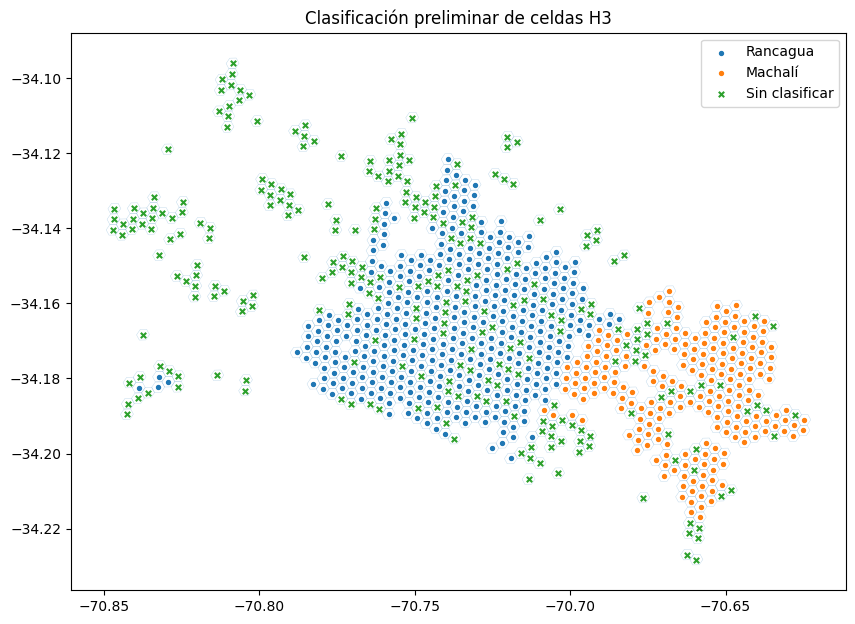

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# todas las celdas como contexto
celdas_estimacion.boundary.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.3
)

# centroides Rancagua
centroides_comuna[
    centroides_comuna['COMUNA'] == 'RANCAGUA'
].plot(
    ax=ax,
    markersize=8,
    label='Rancagua'
)

# centroides Machalí
centroides_comuna[
    centroides_comuna['COMUNA'] == 'MACHALÍ'
].plot(
    ax=ax,
    markersize=8,
    label='Machalí'
)

# centroides sin clasificar
centroides_comuna[
    centroides_comuna['COMUNA'].isna()
].plot(
    ax=ax,
    markersize=15,
    marker='x',
    label='Sin clasificar'
)

ax.legend()
ax.set_title('Clasificación preliminar de celdas H3')
plt.show()

In [19]:
comunas = gpd.read_file("../lab_04/DPA_2023/COMUNAS/COMUNAS_v1.shp")

print(comunas.crs)
print(comunas.columns.tolist())
print(comunas.head())

GEOGCS["GCS_SIRGAS-Chile",DATUM["SIRGAS-Chile",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1254"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
['CUT_REG', 'CUT_PROV', 'CUT_COM', 'REGION', 'PROVINCIA', 'COMUNA', 'SUPERFICIE', 'geometry']
  CUT_REG CUT_PROV CUT_COM                                     REGION  \
0      11      113   11302  Aysén del General Carlos Ibáñez del Campo   
1      05      055   05503                                 Valparaíso   
2      08      083   08308                                     Biobío   
3      09      092   09209                               La Araucanía   
4      09      092   09202                               La Araucanía   

      PROVINCIA      COMUNA  SUPERFICIE  \
0  Capitán Prat   O'Higgins     7784.69   
1      Quillota    Hijuelas      268.12   
2        Biobío     Quilaco     1123.97   
3       Malleco     Renaico      265.40   
4       

In [ ]:
# Códigos CUT oficiales de la capa DPA:
# 06101 = Rancagua
# 06108 = Machalí
#
# Nota: estos códigos son distintos de la variable 'comuna'
# utilizada en agentes.geojson, donde:
# 6101 = Rancagua
# 6102 = Machalí

comunas_rm = comunas[
    comunas['CUT_COM'].isin(['06101', '06108'])
].copy()

print(comunas_rm[['CUT_COM', 'COMUNA']])
print("Número de comunas:", len(comunas_rm))

    CUT_COM    COMUNA
82    06108   Machalí
324   06101  Rancagua
Número de comunas: 2


In [22]:
# llevar límites comunales al mismo CRS de los centroides
comunas_rm = comunas_rm.to_crs(centroides.crs)

# asignar comuna según dónde cae el centroide de cada H3
centroides_comuna_oficial = gpd.sjoin(
    centroides[['h3', 'geometry']],
    comunas_rm[['CUT_COM', 'COMUNA', 'geometry']],
    how='left',
    predicate='within'
)

print("Total:", len(centroides_comuna_oficial))

print("\nComuna:")
print(
    centroides_comuna_oficial['COMUNA']
    .value_counts(dropna=False)
)

Total: 880

Comuna:
COMUNA
Rancagua    604
Machalí     276
Name: count, dtype: int64


In [23]:
# H3 cuyo centroide pertenece oficialmente a Machalí
h3_machali_oficial = centroides_comuna_oficial.loc[
    centroides_comuna_oficial['COMUNA'] == 'Machalí',
    'h3'
]

# Celdas alternativas de Machalí
celdas_machali = celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_machali_oficial)
].copy()

print("Celdas alternativas de Machalí:", len(celdas_machali))

Celdas alternativas de Machalí: 276


In [24]:
agentes_fuera_choice_set = agentes_choice[
    ~agentes_choice['h3'].isin(celdas_machali['h3'])
]

print("Agentes Choice:", len(agentes_choice))
print("Agentes dentro del choice set:",
      agentes_choice['h3'].isin(celdas_machali['h3']).sum())
print("Agentes fuera del choice set:",
      len(agentes_fuera_choice_set))

Agentes Choice: 2679
Agentes dentro del choice set: 2664
Agentes fuera del choice set: 15


In [25]:
print(
    agentes_fuera_choice_set[
        ['id_agente', 'comuna', 'h3', 'destino', 'año']
    ].sort_values('h3')
)

        id_agente  comuna               h3            destino     año
180136       8401    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180137       8402    6102  89b2c1c0b03ffff  habitacional_cat1  2020.0
180138       8403    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180140       8404    6102  89b2c1c0b03ffff  habitacional_cat3  2019.0
180155       8409    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180156       8410    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180658       8448    6102  89b2c1c0b03ffff  habitacional_cat3  2020.0
180661       8449    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180662       8450    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180663       8451    6102  89b2c1c0b03ffff  habitacional_cat3  2020.0
180664       8452    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180665       8453    6102  89b2c1c0b03ffff  habitacional_cat3  2019.0
180666       8454    6102  89b2c1c0b03ffff  habitacional_cat3  2020.0
159755       6072   

In [26]:
print(
    "H3 distintos involucrados:",
    agentes_fuera_choice_set['h3'].nunique()
)

print("\nAgentes por H3:")
print(
    agentes_fuera_choice_set
    .groupby('h3')
    .size()
    .sort_values(ascending=False)
)

H3 distintos involucrados: 2

Agentes por H3:
h3
89b2c1c0b03ffff    13
89b2c1ce5c3ffff     2
dtype: int64


In [27]:
h3_conflicto = [
    '89b2c1c0b03ffff',
    '89b2c1ce5c3ffff'
]

print(
    centroides_comuna_oficial[
        centroides_comuna_oficial['h3'].isin(h3_conflicto)
    ][['h3', 'CUT_COM', 'COMUNA']]
)

                  h3 CUT_COM    COMUNA
497  89b2c1c0b03ffff   06101  Rancagua
855  89b2c1ce5c3ffff   06101  Rancagua


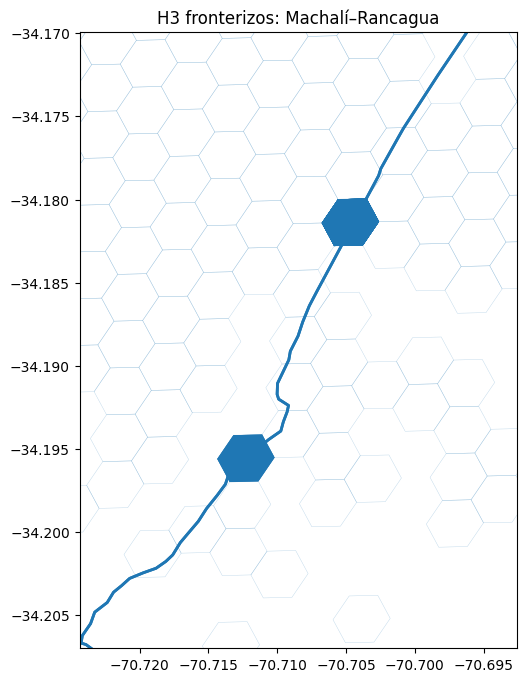

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

# límites oficiales
comunas_rm.boundary.plot(
    ax=ax,
    linewidth=2
)

# todos los H3 alrededor como referencia
celdas_estimacion.boundary.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.3
)

# los dos H3 conflictivos
celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_conflicto)
].plot(
    ax=ax,
    alpha=0.6
)

# ubicaciones de los 15 agentes
agentes_fuera_choice_set.plot(
    ax=ax,
    markersize=25,
    marker='x'
)

# zoom automático alrededor de los dos H3
conflicto = celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_conflicto)
]

xmin, ymin, xmax, ymax = conflicto.total_bounds
margen = 0.01

ax.set_xlim(xmin - margen, xmax + margen)
ax.set_ylim(ymin - margen, ymax + margen)

ax.set_title('H3 fronterizos: Machalí–Rancagua')
plt.show()

El conjunto de alternativas se definió a partir de las celdas H3 cuyos centroides se encuentran dentro del límite administrativo oficial de Machalí. Adicionalmente, se incorporaron dos celdas fronterizas intersectadas por el límite comunal que contienen localizaciones residenciales identificadas como pertenecientes a Machalí en la base de agentes.

In [29]:
# Incorporar los H3 fronterizos que contienen agentes de Machalí
h3_machali_choice = list(h3_machali_oficial) + h3_conflicto

celdas_machali = celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_machali_choice)
].copy()

print("Celdas del choice set:", len(celdas_machali))

print(
    "Agentes dentro del choice set:",
    agentes_choice['h3'].isin(celdas_machali['h3']).sum()
)

print(
    "Agentes fuera del choice set:",
    (~agentes_choice['h3'].isin(celdas_machali['h3'])).sum()
)

Celdas del choice set: 278
Agentes dentro del choice set: 2679
Agentes fuera del choice set: 0


## 4. Variables explicativas del modelo

### 4.1. Selección de variables

In [32]:
variables_explicativas_choice = [
    'dens_viviendas_ha',
    'land_use_mix',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura'
]

### 4.2. Revisión de valores faltantes

In [33]:
df_celdas = celdas_machali[
    ['h3'] + variables_explicativas_choice
].copy()

print(df_celdas.shape)
print(df_celdas.head())

print("\nValores faltantes:")
print(df_celdas[variables_explicativas_choice].isna().sum())

(278, 6)
                 h3  dens_viviendas_ha  land_use_mix  dist_paradero_m  \
1   89b2c1c42cbffff           1.937039      0.416201      5285.837806   
3   89b2c1c54a3ffff          10.125698      0.646580      2738.028722   
13  89b2c1c5523ffff           0.834232      0.279202      4766.129627   
15  89b2c1c094fffff          14.573591      0.543458       151.791968   
19  89b2c1c502fffff           3.074409      0.363838      4121.270338   

    acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
1            3292.533540                        5.130909  
3           23376.814785                       42.328977  
13           7864.230676                       12.768095  
15          51345.176173                       57.570224  
19           5740.590073                        6.198776  

Valores faltantes:
dens_viviendas_ha                 1
land_use_mix                      0
dist_paradero_m                   0
acc_auto_m2_comercio              0
acc_auto_n_educacion_y_cultura    

In [34]:
# revisamos las celdas que tienen valores faltantes en dens_viviendas_ha
celda_nan = df_celdas[
    df_celdas['dens_viviendas_ha'].isna()
]

print(celda_nan)

                  h3  dens_viviendas_ha  land_use_mix  dist_paradero_m  \
566  89b2c1c098fffff                NaN      0.224244       824.052398   

     acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
566          27845.744111                       32.658235  


In [35]:
print(
    celdas_machali.loc[
        celdas_machali['h3'].isin(celda_nan['h3']),
        ['h3', 'personas', 'viviendas', 'area_ha',
         'dens_personas_ha', 'dens_viviendas_ha']
    ]
)

                  h3  personas  viviendas   area_ha  dens_personas_ha  \
566  89b2c1c098fffff       NaN        NaN  8.960882               NaN   

     dens_viviendas_ha  
566                NaN  


In [36]:
h3_nan = '89b2c1c098fffff'

print(
    "Agentes que eligieron esta celda:",
    (agentes_choice['h3'] == h3_nan).sum()
)

Agentes que eligieron esta celda: 24


In [37]:
variables_explicativas_choice = [
    'land_use_mix',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura'
]

df_celdas = celdas_machali[
    ['h3'] + variables_explicativas_choice
].copy()

print("Alternativas:", len(df_celdas))
print("\nValores faltantes:")
print(df_celdas[variables_explicativas_choice].isna().sum())

Alternativas: 278

Valores faltantes:
land_use_mix                      0
dist_paradero_m                   0
acc_auto_m2_comercio              0
acc_auto_n_educacion_y_cultura    0
dtype: int64


## 5. Construcción de la base Choice

### 5.1. Alternativa elegida por cada agente

In [38]:
df_elegida = agentes_choice[
    ['id_agente', 'h3']
].copy()

df_elegida['chosen'] = 1

print(df_elegida.shape)
print(df_elegida.head())

print("\nAgentes únicos:", df_elegida['id_agente'].nunique())
print("H3 elegidos distintos:", df_elegida['h3'].nunique())

(2679, 3)
        id_agente               h3  chosen
154887       5978  89b2c1c54abffff       1
155105       5979  89b2c1c5417ffff       1
155107       5980  89b2c1c5417ffff       1
155126       5981  89b2c1c54d3ffff       1
155146       5982  89b2c1c09b7ffff       1

Agentes únicos: 2679
H3 elegidos distintos: 169


In [40]:
# Todos los agentes
df_agentes = agentes_choice[
    ['id_agente']
].drop_duplicates().copy()

# Producto cartesiano: cada agente x cada alternativa
bd_choice = df_agentes.merge(
    df_celdas,
    how='cross'
)

print("Dimensión:", bd_choice.shape)
print(bd_choice.head())

Dimensión: (744762, 6)
   id_agente               h3  land_use_mix  dist_paradero_m  \
0       5978  89b2c1c42cbffff      0.416201      5285.837806   
1       5978  89b2c1c54a3ffff      0.646580      2738.028722   
2       5978  89b2c1c5523ffff      0.279202      4766.129627   
3       5978  89b2c1c094fffff      0.543458       151.791968   
4       5978  89b2c1c502fffff      0.363838      4121.270338   

   acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
0           3292.533540                        5.130909  
1          23376.814785                       42.328977  
2           7864.230676                       12.768095  
3          51345.176173                       57.570224  
4           5740.590073                        6.198776  


### 5.2. Producto cartesiano agente × alternativa

In [41]:
bd_choice = bd_choice.merge(
    df_elegida[['id_agente', 'h3', 'chosen']],
    on=['id_agente', 'h3'],
    how='left'
)

# Las alternativas que no fueron elegidas reciben chosen = 0
bd_choice['chosen'] = bd_choice['chosen'].fillna(0).astype(int)

### 5.3. Construcción de la variable `chosen`

In [42]:
print("Filas:", len(bd_choice))
print("Chosen = 1:", bd_choice['chosen'].sum())

chosen_por_agente = bd_choice.groupby('id_agente')['chosen'].sum()

print("Mínimo chosen por agente:", chosen_por_agente.min())
print("Máximo chosen por agente:", chosen_por_agente.max())
print("Agentes con exactamente 1 elección:", (chosen_por_agente == 1).sum())

Filas: 744762
Chosen = 1: 2679
Mínimo chosen por agente: 1
Máximo chosen por agente: 1
Agentes con exactamente 1 elección: 2679


## 6. Estimación del modelo Choice

### 6.1. Preparación de las variables explicativas
Antes de estimar el modelo, se reescalan las variables explicativas para facilitar la interpretación de los coeficientes y mejorar la estabilidad numérica de la estimación.

In [43]:
# Crear variables reescaladas para la estimación
bd_choice['mix_usos'] = bd_choice['land_use_mix']

# Distancia expresada en kilómetros
bd_choice['dist_paradero_km'] = (
    bd_choice['dist_paradero_m'] / 1000
)

# Accesibilidad a comercio expresada en decenas de miles
bd_choice['acc_comercio_10k'] = (
    bd_choice['acc_auto_m2_comercio'] / 10000
)

# Accesibilidad a educación expresada en decenas
bd_choice['acc_educacion_10'] = (
    bd_choice['acc_auto_n_educacion_y_cultura'] / 10
)

variables_modelo = [
    'mix_usos',
    'dist_paradero_km',
    'acc_comercio_10k',
    'acc_educacion_10'
]

### 6.2. Revisión de las variables del modelo

Se verifica que las variables explicativas presenten variación y no contengan valores faltantes antes de realizar la estimación.

In [44]:
print(
    bd_choice[variables_modelo]
    .describe()
    .T
)

print("\nValores faltantes:")
print(
    bd_choice[variables_modelo]
    .isna()
    .sum()
)

                     count      mean       std       min       25%       50%  \
mix_usos          744762.0  0.334472  0.114247 -0.000000  0.279202  0.336406   
dist_paradero_km  744762.0  2.464280  1.471918  0.035284  1.237775  2.361379   
acc_comercio_10k  744762.0  1.700036  1.600722  0.068766  0.641944  1.231480   
acc_educacion_10  744762.0  2.223193  1.620498  0.075592  1.010685  1.949161   

                       75%        max  
mix_usos          0.404584   0.646580  
dist_paradero_km  3.661648   5.971583  
acc_comercio_10k  2.182385  10.631135  
acc_educacion_10  3.048240   9.214735  

Valores faltantes:
mix_usos            0
dist_paradero_km    0
acc_comercio_10k    0
acc_educacion_10    0
dtype: int64


### 6.3. Estimación del modelo Multinomial Logit

Se estima un modelo Multinomial Logit (MNL) de elección de localización residencial. Cada agente elige una celda H3 entre las 278 alternativas definidas para Machalí. La utilidad de cada alternativa depende de sus características urbanas y de accesibilidad.

In [45]:
from xlogit import MultinomialLogit

# Matriz de variables explicativas
X = bd_choice[variables_modelo].values

# Alternativa elegida
y = bd_choice['chosen'].values

# Identificador del agente
ids = bd_choice['id_agente'].values

# Identificador de la alternativa
alts = bd_choice['h3'].values

# Nombres de las variables
varnames = variables_modelo

#### 6.3.1 Modelo 1

In [47]:
# Inicializar modelo
modelo_choice = MultinomialLogit()

# Estimar modelo
modelo_choice.fit(
    X=X,
    y=y,
    varnames=varnames,
    ids=ids,
    alts=alts
)

# Mostrar resultados
modelo_choice.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 8
    Function evaluations: 10
Estimation time= 0.9 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
mix_usos               -0.9565687     0.2082620    -4.5931019      4.57e-06 ***
dist_paradero_km       -0.5930334     0.0233204   -25.4297740     5.68e-128 ***
acc_comercio_10k       -1.3308925     0.0585573   -22.7280517     1.03e-104 ***
acc_educacion_10        0.9679676     0.0473455    20.4447458       1.9e-86 ***
---------------------------------------------------------------------------
Significance:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log-Likelihood= -14482.920
AIC= 28973.840
BIC= 28997.412


##### 6.3.1.1 Resultados del Modelo 1

El modelo converge correctamente y las cuatro variables incluidas presentan coeficientes estadísticamente significativos al 1%. Los resultados permiten analizar cómo las características de las celdas se relacionan con la localización observada de nuevos desarrollos residenciales en Machalí durante el período 2018–2022.

##### 6.3.1.2 Diagnóstico del Modelo 1

Se analiza la relación entre las variables explicativas para identificar posibles problemas de correlación y comprender mejor los signos obtenidos en la estimación.

In [48]:
# Correlación entre variables explicativas

correlaciones = (
    df_celdas[
        [
            'land_use_mix',
            'dist_paradero_m',
            'acc_auto_m2_comercio',
            'acc_auto_n_educacion_y_cultura'
        ]
    ]
    .corr()
)

correlaciones.round(3)

,land_use_mix,dist_paradero_m,acc_auto_m2_comercio,acc_auto_n_educacion_y_cultura
land_use_mix,1.000,0.025,0.017,0.154
dist_paradero_m,0.025,1.000,-0.727,-0.723
acc_auto_m2_comercio,0.017,-0.727,1.000,0.945
acc_auto_n_educacion_y_cultura,0.154,-0.723,0.945,1.000


##### 6.3.1.3 Especificaciones alternativas del modelo

El diagnóstico del Modelo 1 muestra una correlación muy alta entre la accesibilidad a comercio y la accesibilidad a educación (r = 0.945). Además, ambas variables presentan una correlación negativa relativamente alta con la distancia al paradero.

Debido a esta colinealidad, los coeficientes del Modelo 1 deben interpretarse con cautela. Se estiman especificaciones alternativas para evaluar la estabilidad de los signos y evitar incluir simultáneamente variables que representan patrones espaciales muy similares.

#### 6.3.2 Modelo 2

In [49]:
# MODELO 2: Mix de usos + distancia a paradero + accesibilidad a comercio

variables_m2 = [
    'mix_usos',
    'dist_paradero_km',
    'acc_comercio_10k'
]

modelo_2 = MultinomialLogit()

modelo_2.fit(
    X=bd_choice[variables_m2].values,
    y=bd_choice['chosen'].values,
    varnames=variables_m2,
    ids=bd_choice['id_agente'].values,
    alts=bd_choice['h3'].values
)

modelo_2.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 8
    Function evaluations: 9
Estimation time= 0.8 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
mix_usos                1.2378811     0.1933898     6.4009644      1.82e-10 ***
dist_paradero_km       -0.5400871     0.0208010   -25.9645115     9.12e-133 ***
acc_comercio_10k       -0.3125420     0.0207503   -15.0620811      2.83e-49 ***
---------------------------------------------------------------------------
Significance:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log-Likelihood= -14697.263
AIC= 29400.526
BIC= 29418.205


#### 6.3.3 Modelo 3

In [50]:
# MODELO 3: Mix de usos + distancia a paradero + accesibilidad a educación

variables_m3 = [
    'mix_usos',
    'dist_paradero_km',
    'acc_educacion_10'
]

modelo_3 = MultinomialLogit()

modelo_3.fit(
    X=bd_choice[variables_m3].values,
    y=bd_choice['chosen'].values,
    varnames=variables_m3,
    ids=bd_choice['id_agente'].values,
    alts=bd_choice['h3'].values
)

modelo_3.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 7
    Function evaluations: 9
Estimation time= 0.8 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
mix_usos                1.1604006     0.1897628     6.1150061      1.11e-09 ***
dist_paradero_km       -0.3962506     0.0196025   -20.2142609      1.11e-84 ***
acc_educacion_10       -0.1268587     0.0170289    -7.4495926      1.26e-13 ***
---------------------------------------------------------------------------
Significance:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log-Likelihood= -14808.395
AIC= 29622.790
BIC= 29640.470


## aaa

In [ ]:
# filtrar por variables y multiplicación matricial con .dot()
variables = ['m2_comercio', 'm2_departamento', 'n_deporte_y_recreacion', 'n_educacion_y_cultura', 'm2_habitacional', 'm2_industria', 'm2_oficina', 'n_salud', 'n_paraderos']

accesibilidades_auto = impedance_auto.dot(celdas[variables])
accesibilidades_caminata = impedance_caminata.dot(celdas[variables])

# renombrar columnas
accesibilidades_auto.columns = [f"acc_auto_{col}" for col in accesibilidades_auto.columns]
accesibilidades_caminata.columns = [f"acc_caminata_{col}" for col in accesibilidades_caminata.columns]

# agregar geometría
accesibilidades_auto = celdas[['h3', 'geometry']].merge(accesibilidades_auto, left_index=True, right_index=True, how='left')
accesibilidades_caminata = celdas[['h3', 'geometry']].merge(accesibilidades_caminata, left_index=True, right_index=True, how='left')

In [ ]:
# definir variables explicativas
variables_explicativas_choice = [
    'acc_auto_m2_comercio', 
    'acc_auto_m2_departamento',
    'acc_auto_n_deporte_y_recreacion', 
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_m2_habitacional', 
    'acc_auto_m2_industria',
    'acc_auto_m2_oficina', 
    'acc_auto_n_salud']

# extraer DataFrame con las columnas de celdas que usaremos de explicativas
df_celdas = celdas_estimacion[['h3'] + variables_explicativas_choice].copy()

# crear DataFrame con la celda elegida
df_elegida = agentes_estimacion[['id_agente', 'h3']].assign(chosen=1)
df_elegida = df_elegida.merge(df_celdas, on='h3', how='left')

# crear el conjunto de elección (producto cartesiano entre agentes y celdas)
all_celdas = df_celdas.assign(key=1)
all_agents = agentes_estimacion[['id_agente']].assign(key=1)
bd_choice = all_agents.merge(all_celdas, on='key', how='left').drop('key', axis=1)

# unir con la información real de la celda elegida
bd_choice = bd_choice.merge(df_elegida[['id_agente', 'h3', 'chosen']], on=['id_agente', 'h3'], how='left')
bd_choice['chosen'] = bd_choice['chosen'].fillna(0)

# reemplazar valores nulos en las variables explicativas con 0
bd_choice[variables_explicativas_choice] = bd_choice[variables_explicativas_choice].fillna(0)

# ver DataFrame final
bd_choice.head()

### Estimación del Modelo *Choice*

A continuación, proporcionaremos todos los argumentos requeridos al método .fit y ajustar así correctamente nuestro modelo *choice* en `xlogit`.

In [ ]:
from xlogit import MultinomialLogit
import pickle

# ajustar el modelo con xlogit
choice_model = MultinomialLogit()
choice_model.fit(
    X=bd_choice[variables_explicativas_choice],
    y=bd_choice['chosen'],
    varnames=variables_explicativas_choice,
    ids=bd_choice['id_agente'],
    alts=bd_choice['h3'])

# guardar el modelo en .pickle
with open("choice.pickle", "wb") as file:
    pickle.dump(choice_model, file)

# mostrar resumen del modelo
choice_model.summary()

Cabe señalar que el modelo estimado en este laboratorio es incompleto: falta incorporar un **modelo hedónico de precios a partir de una Regresión Lineal Múltiple** usando `statsmodels` u otras librerías similares.

---

## 5. Modelo Bid (con *`biogeme`*)

El modelo Bid asume que la localización es “ganada” por una categoría / uso de suelo. A modo representativo, en este laboratorio consideraremos que sólo los agentes habitacionales "pujan" por una localización, por lo cual definiremos las categorías $c \in \{1,2,3\}$ en función de la calidad de la construcción. Con ello, definimos la disposición a pagar (*willingness to pay*, WTP) de cada categoría  $c$  por una localización  $i$  de la siguiente manera.

$WTP_{c,i} = \beta_{c,0} + \beta_{c,1} \cdot X_{i,1} + \beta_{c,2} \cdot X_{i,2} + \dots$

En este caso,

- $\beta_{c,k}$  son los coeficientes a estimar para la categoría  $c$  y variable $k$.
- $X_{i,k}$  son las variables explicativas de la localización  $i$.

La probabilidad de que la categoría  $c$  gane la subasta por la localización  $i$  se define a continuación.

$P_{i}(c) = \frac{\exp(WTP_{c,i})}{\sum_{k} \exp(WTP_{k,i})}$

Para evitar colinealidad, fijamos el intercepto de una categoría (por ejemplo,  $c = 1$ ) a cero.

### Preparación de la Base de Datos *Bid*

En el siguiente ejemplo, consideraremos un conjunto de variables explicativas para preparar nuestro modelo Bid para `biogeme`.

In [ ]:
import biogeme.database as db

# seleccionar las columnas relevantes para el modelo bid
variables_explicativas_bid = ['acc_auto_m2_comercio', 'acc_auto_n_educacion_y_cultura', 'acc_auto_m2_habitacional', 'acc_auto_m2_industria', 'acc_auto_n_salud']

# extraer DataFrame con las columnas de celdas que usaremos de explicativas
df_celdas = celdas_estimacion[['h3', 'id_celda'] + variables_explicativas_bid].copy()

# preparar la base de datos para biogeme
bd_bid = agentes_estimacion.merge(df_celdas, on='h3', how='left', suffixes=('_ag','_cell'))

# seleccionar solo las columnas necesarias
bd_bid = bd_bid[['id_agente','cat_vivienda', 'superficie_construida', 'id_celda'] + variables_explicativas_bid]

# ver las primeras filas
bd_bid.head()

In [ ]:
# definir la base de datos para biogeme
database = db.Database('Bid', bd_bid)
globals().update(database.variables)

### Estimación del Modelo *Bid*

A continuación, proporcionaremos todos los argumentos requeridos al método .estimate y ajustar así correctamente nuestro modelo *bid* en `biogeme`. Nuevamente, es importante recordar que el modelo Bid estimado en este laboratorio es representativo, considerando que **se requiere estudiar diferentes especificaciones que combinen accesibilidades en diferentes modos de transporte**, de acuerdo a lo revisado en el Laboratorio 3. 

In [ ]:
from biogeme import models
from biogeme.expressions import Beta
import biogeme.biogeme as bio

# definir las variables y categorías
xh = ['C']
zi = variables_explicativas_bid
total_vars = xh+zi
categorias = 3

# definir los parámetros a estimar
betas = {}
for c in range(1, categorias + 1):
    for v in total_vars:
        if c == 1:
            fixed = 1
        else:
            fixed = 0
        aux_beta = Beta(f'B_{v}_H{c}', 0, -100, 100, fixed)
        betas.update({f'B_{v}_H{c}': aux_beta})

# definir la disposición a pagar de cada categoría
V = {}
av = {}
for c in range(1, categorias + 1):
    DP_aux = 0
    for v in xh:
        DP_aux += betas[f'B_{v}_H{c}']
    for v in zi:
        DP_aux += betas[f'B_{v}_H{c}']*database.variables[v]
    V.update({c: DP_aux})
    av.update({c: 1})

# definir la log-verosimilitud
logprob = models.loglogit(V, av, cat_vivienda)

# (opcional) definir el peso de cada observación
bio.WEIGHT = superficie_construida

# crear el objeto biogeme y estimar el modelo
biogeme = bio.BIOGEME(database, logprob)
biogeme.modelName = 'bid'
bid_model = biogeme.estimate()

# guardar el modelo en .pickle
with open("bid.pickle", "wb") as file:
    pickle.dump(bid_model, file)

Con esto completamos el Laboratorio 4 sobre estimación de modelos de localización basados en un enfoque *bid* y *choice* con las librerías `xlogit` y `Biogeme` de Python.

**Fin del Laboratorio 4**

---

En el próximo laboratorio, exploraremos cómo utilizar nuestros estimadores de los modelos de localización para simular nuevas localizaciones futuras.